In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Google Colab에서 GitHub 레포지토리 클론
!git clone https://github.com/patrick-knab/dseg-lime.git
%cd dseg-lime


Cloning into 'dseg-lime'...
remote: Enumerating objects: 168, done.
remote: Counting objects: 100% (168/168), done.
remote: Compressing objects: 100% (126/126), done.
remote: Total 168 (delta 68), reused 119 (delta 41), pack-reused 0 (from 0)
Receiving objects: 100% (168/168), 13.47 MiB | 10.56 MiB/s, done.
Resolving deltas: 100% (68/68), done.
Updating files: 100% (103/103), done.
/content/drive/My Drive/dseg-lime/dseg-lime


In [ ]:
cd "/content/drive/MyDrive/dseg-lime/"

/content/drive/MyDrive/dseg-lime


In [ ]:
# 필요한 라이브러리 설치
!pip install -r requirements.txt


In [ ]:
pip install torch==2.5.1


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 906.4/906.4 MB 1.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 54.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 46.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 37.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 12.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 188.7/188.7 MB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 47.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [ ]:
!pip install git+https://github.com/facebookresearch/segment-anything.git


  Cloning https://github.com/facebookresearch/segment-anything.git to /tmp/pip-req-build-b0vn_qg7
  Running command git clone --filter=blob:none --quiet https://github.com/facebookresearch/segment-anything.git /tmp/pip-req-build-b0vn_qg7
  Resolved https://github.com/facebookresearch/segment-anything.git to commit dca509fe793f601edb92606367a655c15ac00fdf
  Preparing metadata (setup.py) ... done


In [ ]:
from segment_anything import sam_model_registry, SamAutomaticMaskGenerator
print("segment-anything imported successfully!")


segment-anything imported successfully!


In [ ]:
from __future__ import print_function, division
import torch
from PIL import Image
from segment_anything import sam_model_registry, SamAutomaticMaskGenerator
import matplotlib.pyplot as plt
from torchvision import transforms
import numpy as np
from torchvision.models.feature_extraction import create_feature_extractor
from torchvision import transforms
from tensorflow.keras.applications.efficientnet import decode_predictions

In [ ]:
model = torch.hub.load('pytorch/vision:v0.10.0', 'resnet101', pretrained=True)
cvmodel = model
cvmodel.eval()
feat_exp = create_feature_extractor(cvmodel, return_nodes=['avgpool'])
fc = model.fc
model.eval()
feat_exp.eval()
cvmodel.eval()

Using cache found in /root/.cache/torch/hub/pytorch_vision_v0.10.0


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

In [ ]:
!wget -P /content/drive/MyDrive/dseg-lime/Models/pretrained/ https://dl.fbaipublicfiles.com/segment_anything/sam_vit_h_4b8939.pth


--2024-12-15 12:17:06--  https://dl.fbaipublicfiles.com/segment_anything/sam_vit_h_4b8939.pth
Resolving dl.fbaipublicfiles.com (dl.fbaipublicfiles.com)... 13.226.210.15, 13.226.210.25, 13.226.210.78, ...
Connecting to dl.fbaipublicfiles.com (dl.fbaipublicfiles.com)|13.226.210.15|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 2564550879 (2.4G) [binary/octet-stream]
Saving to: ‘/content/drive/MyDrive/dseg-lime/Models/pretrained/sam_vit_h_4b8939.pth.5’

sam_vit_h_4b8939.pt 100%[===================>]   2.39G  36.3MB/s    in 77s     

2024-12-15 12:18:23 (31.9 MB/s) - ‘/content/drive/MyDrive/dseg-lime/Models/pretrained/sam_vit_h_4b8939.pth.5’ saved [2564550879/2564550879]



Config.md        dseg-lime/                LICENSE    requirements.txt
Dataset/         Evaluation_Quantitative/  Models/    User-Study-Evaluation.ipynb
DSEG_Demo.ipynb  Experiments/              ReadMe.md  Utilities/


# SAM을 사용하여 이미지에서 마스크를 자동으로 생성하는 역할

In [ ]:
from segment_anything import SamAutomaticMaskGenerator, sam_model_registry

sam_checkpoint = "/content/drive/MyDrive/dseg-lime/Models/pretrained/sam_vit_h_4b8939.pth"
model_type = "vit_h"

# 모델 로드
sam = sam_model_registry[model_type](checkpoint=sam_checkpoint)
mask_generator = SamAutomaticMaskGenerator(sam,
                                           min_mask_region_area=512,
                                           points_per_side=32)
print("SAM 모델이 정상적으로 로드되었습니다.")


SAM 모델이 정상적으로 로드되었습니다.


In [ ]:
test_preprocess = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
]) ### a complete imagenet data pre-process

image_reshape = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
]) ### process the imagenet data to sam

image_norm = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
]) ### imagenet std and mean

class ImageModel:
    def __init__(self, model, test_preprocess):
        self.model = model
        self.test_preprocess = test_preprocess

    def predict (self, image_data):
        first_dim = 1 if len(image_data.shape) == 3 else len(image_data)
        image_data = image_data.reshape(first_dim, image_data.shape[1], image_data.shape[2], 3)

        # Convert numpy array to PIL Images
        image_data_pil = [Image.fromarray(local_img) for local_img in image_data]
        # Apply preprocessing
        preprocessed_images = [test_preprocess(img).unsqueeze(0) for img in image_data_pil]

        # Stack preprocessed images into a batch tensor
        batch_tensor = torch.cat(preprocessed_images, dim=0)

        # Pass the batch tensor through the model
        scores = self.model(batch_tensor)
        return scores

image_model = ImageModel(model, test_preprocess)
def lime_explanation_function(images):
    scores = image_model.predict(images)
    scores_np = scores.detach().numpy()
    return scores_np

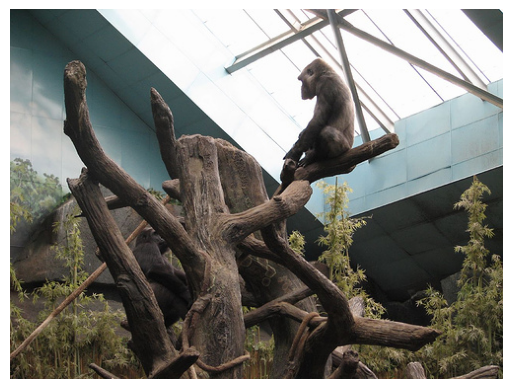

torch.Size([1, 1000])

In [ ]:
img_path = "./Dataset/Evaluation/n02480855_gorilla.JPEG"
img = Image.open(img_path).convert('RGB')

plt.imshow(img)
plt.axis(False)
plt.show()
plt.close()
predict_org = torch.nn.functional.softmax(cvmodel(test_preprocess(img).unsqueeze(0)),dim=1)
predict_org.shape



In [ ]:
arg_position = 1
pred_image_class = torch.sort(predict_org, descending=True).indices[0][arg_position].item()
label_class = decode_predictions(predict_org.detach().numpy().reshape(1, -1))
print(label_class)
print(pred_image_class)

In [ ]:
!pip install efficientnet

# DSEG-LIME실행

모델의 예측에 대한 설명을 포함한 객체가 출력된 (이미지에서 중요한 영역의 마스크, 각 영역이 모델 예측에 미친 기여도(중요도))


In [ ]:
from Utilities.dseg_lime import DSEG_Lime

explainer = DSEG_Lime()
img = Image.open(img_path).convert('RGB')
for_mask_image = np.array((img))
explanation = explainer.explain_instance(image = for_mask_image,
                                        classifier_fn=lime_explanation_function,
                                        feature_extractor=mask_generator,
                                        model = sam,
                                        image_path = img_path,
                                        iterations = 1)


이미지에서 모델 예측에 가장 큰 영향을 미친 중요 영역만 표시

In [ ]:
temp, mask = explanation.get_image_and_mask(explanation.top_labels[0], positive_only=True, num_features=1, hide_rest=True)
# Convert mask to 3D
mask_3d = np.stack([mask] * 3, axis=-1)
# Create a white background image
white_background = np.ones_like(np.array(for_mask_image)) * 255
# Blend the original image with the white background using the mask
image_with_mask = np.where(mask_3d, np.array(for_mask_image), white_background)
# Display the image with boundaries
plt.imshow(image_with_mask)
plt.axis(False)
plt.show()

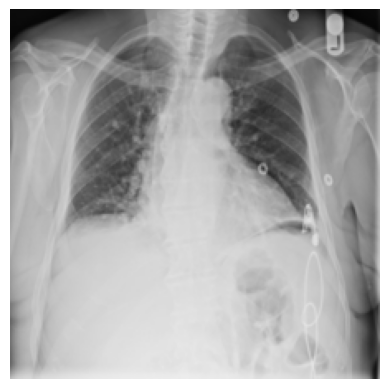

torch.Size([1, 1000])

In [ ]:
img_path = "/content/drive/MyDrive/00003279_001.png"
img = Image.open(img_path).convert('RGB')

plt.imshow(img)
plt.axis(False)
plt.show()
plt.close()
predict_org = torch.nn.functional.softmax(cvmodel(test_preprocess(img).unsqueeze(0)),dim=1)
predict_org.shape



In [ ]:
arg_position = 1
pred_image_class = torch.sort(predict_org, descending=True).indices[0][arg_position].item()
label_class = decode_predictions(predict_org.detach().numpy().reshape(1, -1))
print(label_class)
print(pred_image_class)

[[('n03388043', 'fountain', 0.43391362), ('n04209239', 'shower_curtain', 0.09247634), ('n01910747', 'jellyfish', 0.052223925), ('n01484850', 'great_white_shark', 0.044930127), ('n10148035', 'groom', 0.032957498)]]
794


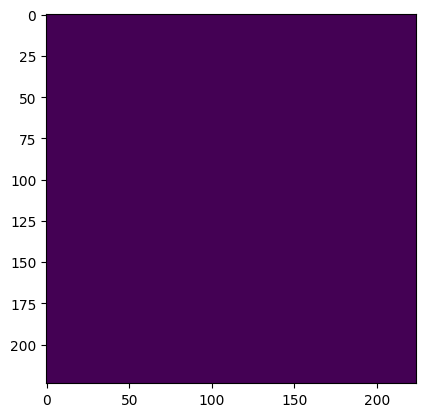

  0%|          | 0/256 [00:00<?, ?it/s]

In [ ]:
from Utilities.dseg_lime import DSEG_Lime

explainer = DSEG_Lime()
img = Image.open(img_path).convert('RGB')
for_mask_image = np.array((img))
explanation = explainer.explain_instance(image = for_mask_image,
                                        classifier_fn=lime_explanation_function,
                                        feature_extractor=mask_generator,
                                        model = sam,
                                        image_path = img_path,
                                        iterations = 1)


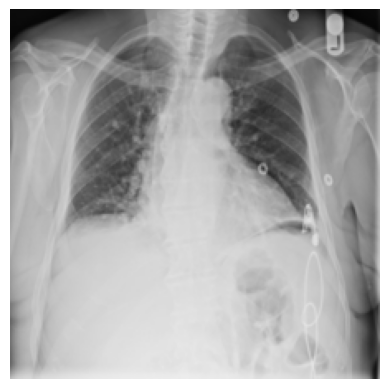

In [ ]:
temp, mask = explanation.get_image_and_mask(explanation.top_labels[0], positive_only=True, num_features=1, hide_rest=True)
# Convert mask to 3D
mask_3d = np.stack([mask] * 3, axis=-1)
# Create a white background image
white_background = np.ones_like(np.array(for_mask_image)) * 255
# Blend the original image with the white background using the mask
image_with_mask = np.where(mask_3d, np.array(for_mask_image), white_background)
# Display the image with boundaries
plt.imshow(image_with_mask)
plt.axis(False)
plt.show()